# Phân loại và Dự đoán Bệnh Tiểu đường (Diabetes)
## Sử dụng Pima Indians Diabetes Dataset

## 1. Định nghĩa vấn đề (Define Problem)
+ **Mô tả**:
    + Bộ dữ liệu bao gồm 768 mẫu từ các bệnh nhân của người Ấn Độ Pima.
    + Tám đặc điểm y tế được đo từ mỗi bệnh nhân.
    + Mục tiêu: Dự đoán xem bệnh nhân có bị bệnh tiểu đường hay không (phân loại nhị phân).
+ **Dữ liệu vào (Input Features)**:
    + Pregnancies: Số lần mang thai
    + Glucose: Nồng độ glucose trong máu (mg/dL)
    + BloodPressure: Huyết áp tâm trương (mmHg)
    + SkinThickness: Độ dày da tại cơ ba đầu (mm)
    + Insulin: Nồng độ insulin 2 giờ sau (µU/mL)
    + BMI: Chỉ số khối cơ thể (kg/m²)
    + DiabetesPedigreeFunction: Hàm lịch sử bệnh tiểu đường gia đình
    + Age: Tuổi (năm)
+ **Kết quả (Output/Target)**:
    + Outcome: 0 (Không bị bệnh tiểu đường) hoặc 1 (Bị bệnh tiểu đường)

## 2. Nhập thư viện và tải dữ liệu (Import Libraries & Load Data)

In [1]:
# Nhập các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')
import joblib, os, json as _json

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
print("✓ Thư viện đã được nhập thành công!")

✓ Thư viện đã được nhập thành công!


In [2]:
# Tải dữ liệu từ file CSV
# Đặt tên cột vì file CSV không có header
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv('data/pima-indians-diabetes.csv', header=None, names=column_names)

print(f"Kích thước dữ liệu: {df.shape}")
print(f"\n10 dòng đầu tiên:")
print(df.head(10))

Kích thước dữ liệu: (768, 9)

10 dòng đầu tiên:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   
5            5      116             74              0        0  25.6   
6            3       78             50             32       88  31.0   
7           10      115              0              0        0  35.3   
8            2      197             70             45      543  30.5   
9            8      125             96              0        0   0.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672

## 3. Khám phá và Phân tích dữ liệu (Exploratory Data Analysis - EDA)

### 3.1 Hướng dẫn (Guidance)
+ **Mục tiêu**: Hiểu rõ dữ liệu trước khi xây dựng mô hình
+ **Các bước thực hiện**:
    1. Kiểm tra kích thước và kiểu dữ liệu
    2. Xem thống kê mô tả (mean, std, min, max)
    3. Phân tích phân bố lớp (class distribution)
    4. Tính tương quan giữa các đặc trưng
    5. Vẽ biểu đồ để trực quan hóa
+ **Nhận xét**:
    - Glucose có tương quan cao nhất với Outcome (0.47)
    - Dữ liệu không cân bằng: 65.1% không bệnh, 34.9% có bệnh
    - Một số giá trị 0 bất thường (Glucose=0, BloodPressure=0 không hợp lý y tế)
    - Cần xử lý giá trị bất thường trước huấn luyện

In [3]:
# Xem thông tin tổng quan về dữ liệu
print("Thông tin dữ liệu:")
print(df.info())
print(f"\n" + "="*80)
print(f"\nThống kê mô tả:")
print(df.describe())
print(f"\n" + "="*80)
print(f"\nGiá trị bị thiếu:")
print(df.isnull().sum())

Thông tin dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


Thống kê mô tả:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536


Phân bố lớp (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64

Tỷ lệ phần trăm:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


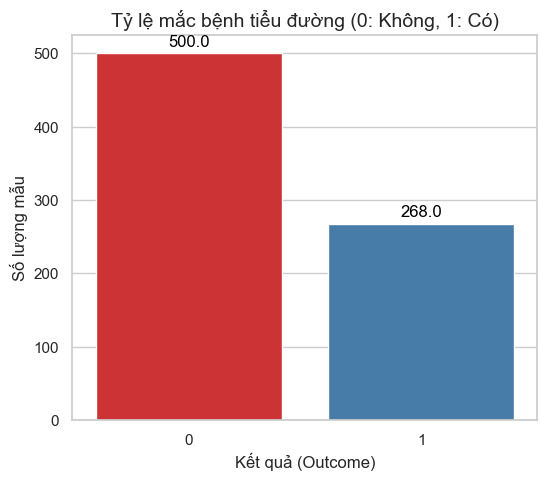

In [4]:
# ---------------------------------------------------------
# BIỂU ĐỒ 1: Tỷ lệ người mắc bệnh tiểu đường
# ---------------------------------------------------------
# In thống kê phân bố lớp
print(f"\nPhân bố lớp (Outcome):")
print(df['Outcome'].value_counts())
print(f"\nTỷ lệ phần trăm:")
print(df['Outcome'].value_counts(normalize=True) * 100)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='Outcome', data=df, palette='Set1')
plt.title('Tỷ lệ mắc bệnh tiểu đường (0: Không, 1: Có)', fontsize=14)
plt.xlabel('Kết quả (Outcome)')
plt.ylabel('Số lượng mẫu')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

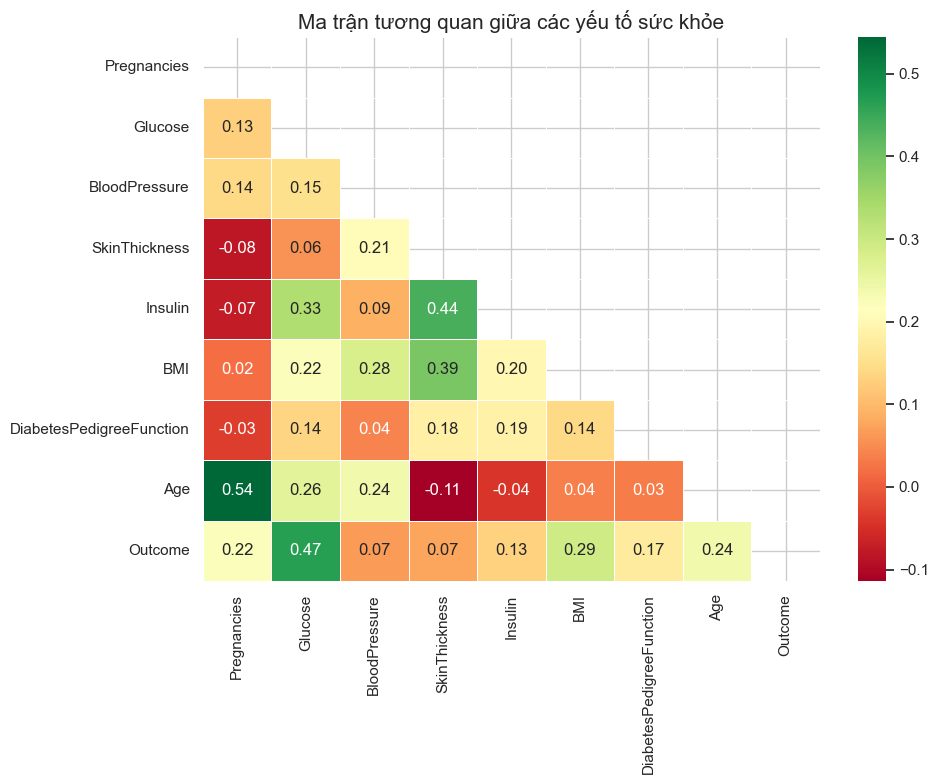


Tương quan với Outcome:
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [5]:
# ---------------------------------------------------------
# BIỂU ĐỒ 2: Ma trận tương quan (Heatmap)
# ---------------------------------------------------------
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các yếu tố sức khỏe', fontsize=15)
plt.tight_layout()
plt.show()

# Hiển thị tương quan với Outcome
print("\nTương quan với Outcome:")
outcome_corr = correlation_matrix['Outcome'].sort_values(ascending=False)
print(outcome_corr)

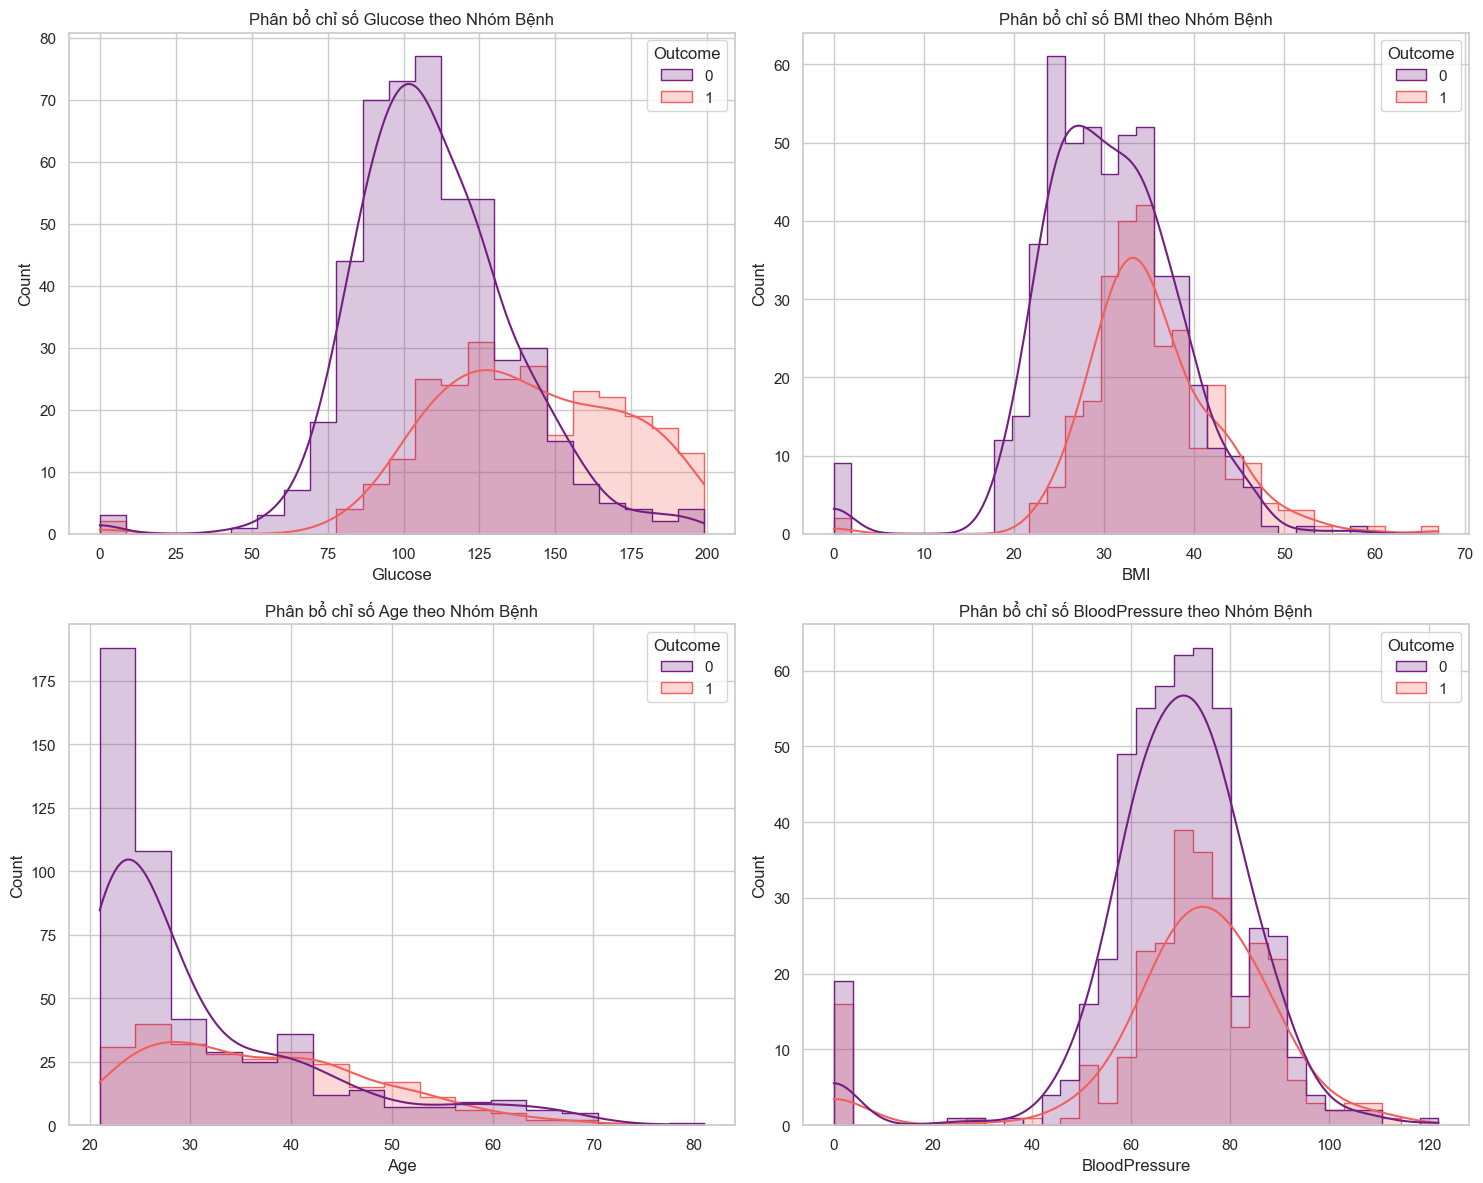

In [6]:
# ---------------------------------------------------------
# BIỂU ĐỒ 3: Phân bổ các chỉ số quan trọng (Glucose, BMI, Age, BloodPressure)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

important_features = ['Glucose', 'BMI', 'Age', 'BloodPressure']

for i, col in enumerate(important_features):
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, ax=axes[i//2, i%2], palette='magma', element="step")
    axes[i//2, i%2].set_title(f'Phân bổ chỉ số {col} theo Nhóm Bệnh', fontsize=12)

plt.tight_layout()
plt.show()

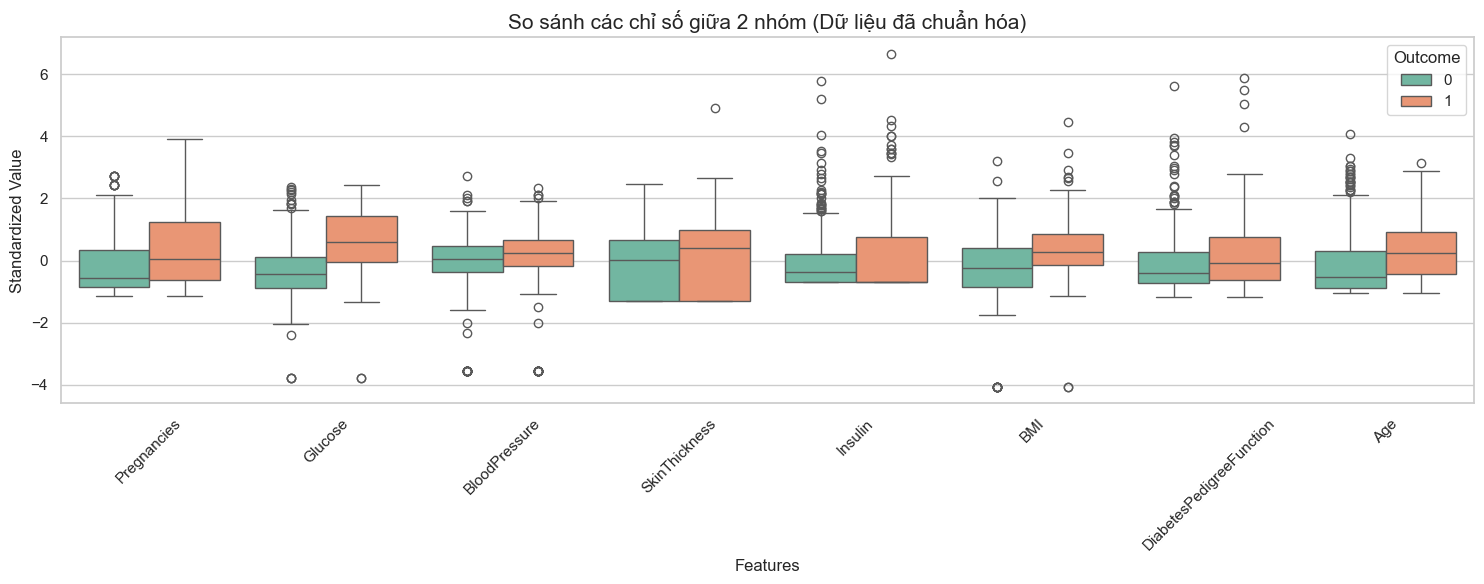

In [7]:
# ---------------------------------------------------------
# BIỂU ĐỒ 4: Boxplot so sánh các chỉ số giữa 2 nhóm (Dữ liệu đã chuẩn hóa)
# ---------------------------------------------------------
plt.figure(figsize=(15, 6))
features = df.columns[:-1]
df_melted = df.drop('Outcome', axis=1)
df_norm = (df_melted - df_melted.mean()) / df_melted.std()
df_norm['Outcome'] = df['Outcome']
df_plot = pd.melt(df_norm, id_vars='Outcome', var_name='Features', value_name='Standardized Value')

sns.boxplot(x='Features', y='Standardized Value', hue='Outcome', data=df_plot, palette='Set2')
plt.xticks(rotation=45)
plt.title('So sánh các chỉ số giữa 2 nhóm (Dữ liệu đã chuẩn hóa)', fontsize=15)
plt.tight_layout()
plt.show()

## 4. Tiền xử lý dữ liệu (Data Preprocessing)

### 4.1 Hướng dẫn (Guidance)
+ **Bước 1: Xử lý giá trị 0 bất thường**
    - Thay giá trị 0 bằng trung bình (mean) của các giá trị khác 0
    - Áp dụng cho: Glucose, BloodPressure, SkinThickness, Insulin, BMI
+ **Bước 2: Tách Features và Target**
    - X = tất cả cột trừ Outcome ; y = cột Outcome
+ **Bước 3: Chia dữ liệu Hold-out (Train/Test = 7/3)**
    - 70% training, 30% testing ; dùng `stratify=y`
+ **Bước 4: Chuẩn bị 3 phiên bản dữ liệu**
    - **Thô (Raw)**: không chuẩn hóa
    - **MinMaxScaler**: chuẩn hóa về [0, 1]
    - **StandardScaler**: chuẩn hóa về mean=0, std=1

In [8]:
# Kiểm tra và xử lý các giá trị 0 không hợp lý
# Các biến như Glucose, BloodPressure, BMI không nên có giá trị 0
print("Số lượng giá trị 0 trong mỗi cột:")
zero_count = (df == 0).sum()
print(zero_count)
print(f"\nTổng số giá trị 0: {zero_count.sum()}")

# Hiển thị các hàng có giá trị 0
print(f"\nPercentage of zeros in each column:")
for col in zero_count.index:
    if col != 'Outcome':
        pct = (zero_count[col] / len(df)) * 100
        print(f"  {col}: {pct:.2f}%")

Số lượng giá trị 0 trong mỗi cột:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

Tổng số giá trị 0: 1263

Percentage of zeros in each column:
  Pregnancies: 14.45%
  Glucose: 0.65%
  BloodPressure: 4.56%
  SkinThickness: 29.56%
  Insulin: 48.70%
  BMI: 1.43%
  DiabetesPedigreeFunction: 0.00%
  Age: 0.00%


In [9]:
# Thay thế giá trị 0 bằng trung bình (ngoại trừ Pregnancies và Outcome)
# Pregnancies có thể là 0, nhưng các biến khác thì không nên
columns_to_fill = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Xử lý giá trị 0 bằng cách thay thế bằng trung bình:")
for col in columns_to_fill:
    mean_val = df[col][df[col] != 0].mean()
    df[col].replace(0, mean_val, inplace=True)
    print(f"  {col}: Thay 0 bằng {mean_val:.2f}")

print("\nSau khi xử lý:")
print((df == 0).sum())

Xử lý giá trị 0 bằng cách thay thế bằng trung bình:
  Glucose: Thay 0 bằng 121.69
  BloodPressure: Thay 0 bằng 72.41
  SkinThickness: Thay 0 bằng 29.15
  Insulin: Thay 0 bằng 155.55
  BMI: Thay 0 bằng 32.46

Sau khi xử lý:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [10]:
# Kiểm tra thống kê sau khi xử lý
print("Thống kê sau khi xử lý dữ liệu:")
print(df.describe())

Thống kê sau khi xử lý dữ liệu:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min

In [11]:
# Tách Features / Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print(f"Hình dạng X: {X.shape}  |  y: {y.shape}")
print(f"Các đặc trưng: {list(X.columns)}")

# Chia dữ liệu Hold-out 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTập huấn luyện : {X_train.shape[0]} mẫu ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Tập kiểm tra   : {X_test.shape[0]}  mẫu ({X_test.shape[0]/len(X)*100:.1f}%)")

# Phân bố lớp
print(f"\nTỷ lệ lớp train: {dict(y_train.value_counts(normalize=True).round(3))}")
print(f"Tỷ lệ lớp test : {dict(y_test.value_counts(normalize=True).round(3))}")

Hình dạng X: (768, 8)  |  y: (768,)
Các đặc trưng: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Tập huấn luyện : 537 mẫu (69.9%)
Tập kiểm tra   : 231  mẫu (30.1%)

Tỷ lệ lớp train: {0: np.float64(0.652), 1: np.float64(0.348)}
Tỷ lệ lớp test : {0: np.float64(0.649), 1: np.float64(0.351)}


In [12]:
# Chuẩn bị 3 phiên bản dữ liệu
# 1. Dữ liệu thô (Raw) - không chuẩn hóa
X_train_raw  = X_train.values
X_test_raw   = X_test.values

# 2. Chuẩn hóa Min/Max
minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax  = minmax_scaler.transform(X_test)

# 3. Chuẩn hóa Standard (Z-score)
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std  = std_scaler.transform(X_test)

datasets = {
    'Raw (Thô)'        : (X_train_raw,    X_test_raw),
    'MinMax Scaled'    : (X_train_minmax,  X_test_minmax),
    'Standard Scaled'  : (X_train_std,     X_test_std),
}

print("✓ 3 phiên bản dữ liệu đã được chuẩn bị:")
for name, (tr, te) in datasets.items():
    print(f"  [{name}]  train={tr.shape}  test={te.shape}")
    print(f"    mean={tr.mean():.4f}  std={tr.std():.4f}  min={tr.min():.4f}  max={tr.max():.4f}")

✓ 3 phiên bản dữ liệu đã được chuẩn bị:
  [Raw (Thô)]  train=(537, 8)  test=(231, 8)
    mean=44.8723  std=56.6002  min=0.0000  max=744.0000
  [MinMax Scaled]  train=(537, 8)  test=(231, 8)
    mean=0.3395  std=0.2514  min=0.0000  max=1.0000
  [Standard Scaled]  train=(537, 8)  test=(231, 8)
    mean=0.0000  std=1.0000  min=-4.1201  max=6.1271


## 5. Lượng giá thuật toán - Baselines (Evaluate Algorithms)

### 5.1 Hướng dẫn
+ **6 mô hình tham số mặc định**: Logistic Regression, Linear Discriminant Analysis,  
  K-Neighbors, Decision Tree, Gaussian Naive Bayes, SVM  
+ **Chiến lược validation**: K-Fold (k=10) trên tập train  
+ **Đánh giá**: Accuracy trung bình ± độ lệch chuẩn trên mỗi fold  
+ **Thực hiện trên cả 3 phiên bản dữ liệu**: Raw, MinMax, Standard

In [13]:
# Khởi tạo 6 mô hình tham số mặc định
models_baseline = [
    ('LR',  LogisticRegression(max_iter=1000, random_state=42)),
    ('LDA', LinearDiscriminantAnalysis()),
    ('KNN', KNeighborsClassifier()),
    ('DT',  DecisionTreeClassifier(random_state=42)),
    ('GNB', GaussianNB()),
    ('SVM', SVC(kernel='rbf', probability=True, random_state=42)),
]

# K-Fold 10 fold
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

baseline_results = {}   # lưu kết quả để so sánh

print("=" * 75)
print(f"{'MODEL':<6} {'RAW':>18} {'MINMAX':>20} {'STANDARD':>20}")
print("=" * 75)

for name, model in models_baseline:
    row = {}
    for ds_name, (X_tr, _) in datasets.items():
        scores = cross_val_score(model, X_tr, y_train,
                                 cv=kfold, scoring='accuracy')
        row[ds_name] = scores
    baseline_results[name] = row

    r   = row['Raw (Thô)']
    mm  = row['MinMax Scaled']
    std = row['Standard Scaled']
    print(f"{name:<6}  {r.mean():.4f} ± {r.std():.4f}   "
          f"{mm.mean():.4f} ± {mm.std():.4f}   "
          f"{std.mean():.4f} ± {std.std():.4f}")

print("=" * 75)
print("(mean ± std accuracy qua 10-fold trên tập train)")

MODEL                 RAW               MINMAX             STANDARD
LR      0.7823 ± 0.0592   0.7730 ± 0.0558   0.7805 ± 0.0624
LDA     0.7749 ± 0.0671   0.7749 ± 0.0671   0.7749 ± 0.0671
KNN     0.7189 ± 0.0474   0.7635 ± 0.0576   0.7283 ± 0.0492
DT      0.6817 ± 0.0587   0.6798 ± 0.0612   0.6835 ± 0.0568
GNB     0.7599 ± 0.0634   0.7599 ± 0.0634   0.7599 ± 0.0634
SVM     0.7563 ± 0.0631   0.7636 ± 0.0433   0.7693 ± 0.0390
(mean ± std accuracy qua 10-fold trên tập train)


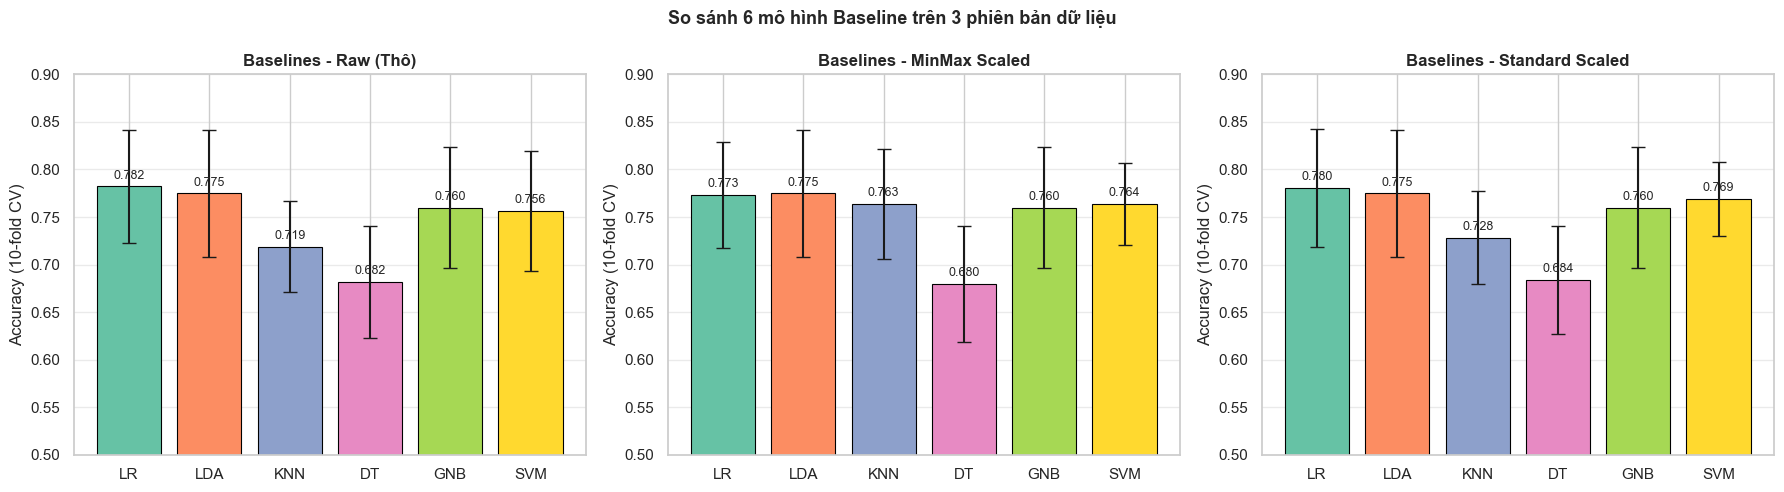

In [14]:
# Trực quan hóa kết quả Baselines
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ds_names  = list(datasets.keys())
model_names = list(baseline_results.keys())

for ax, ds_name in zip(axes, ds_names):
    means = [baseline_results[m][ds_name].mean() for m in model_names]
    stds  = [baseline_results[m][ds_name].std()  for m in model_names]
    bars  = ax.bar(model_names, means, yerr=stds, capsize=5,
                   color=sns.color_palette('Set2', len(model_names)),
                   edgecolor='black', linewidth=0.8)
    ax.set_title(f'Baselines - {ds_name}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Accuracy (10-fold CV)')
    ax.set_ylim(0.5, 0.9)
    ax.grid(axis='y', alpha=0.4)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('So sánh 6 mô hình Baseline trên 3 phiên bản dữ liệu',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Tinh chỉnh tham số - K-Neighbors & SVM

### 6.1 Hướng dẫn
+ **Tinh chỉnh KNN**: tìm giá trị `n_neighbors` tốt nhất  
+ **Tinh chỉnh SVM**: tìm tổ hợp `C` và `gamma` tốt nhất  
+ Dùng `GridSearchCV` với K-Fold (k=10) trên **StandardScaler** (thường tốt nhất cho KNN, SVM)  
+ So sánh với mô hình tham số mặc định

In [15]:
# Tinh chỉnh KNN
print("── TINH CHỈNH KNN ──")
knn_params = {
    'n_neighbors': list(range(1, 31, 2)),   # 1, 3, 5, ..., 29
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(), knn_params,
    cv=kfold, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_std, y_train)

best_knn = knn_grid.best_estimator_
print(f"Tham số tốt nhất : {knn_grid.best_params_}")
print(f"Accuracy (CV)    : {knn_grid.best_score_:.4f}")

# So sánh với default
default_knn_score = baseline_results['KNN']['Standard Scaled'].mean()
print(f"\nDefault KNN (CV) : {default_knn_score:.4f}")
print(f"Cải thiện        : {knn_grid.best_score_ - default_knn_score:+.4f}")

── TINH CHỈNH KNN ──
Tham số tốt nhất : {'metric': 'manhattan', 'n_neighbors': 23, 'weights': 'distance'}
Accuracy (CV)    : 0.7656

Default KNN (CV) : 0.7283
Cải thiện        : +0.0373


In [16]:
# Tinh chỉnh SVM
print("── TINH CHỈNH SVM ──")
svm_params = {
    'C'    : [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42), svm_params,
    cv=kfold, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_std, y_train)

best_svm = svm_grid.best_estimator_
print(f"Tham số tốt nhất : {svm_grid.best_params_}")
print(f"Accuracy (CV)    : {svm_grid.best_score_:.4f}")

# So sánh với default
default_svm_score = baseline_results['SVM']['Standard Scaled'].mean()
print(f"\nDefault SVM (CV) : {default_svm_score:.4f}")
print(f"Cải thiện        : {svm_grid.best_score_ - default_svm_score:+.4f}")

── TINH CHỈNH SVM ──
Tham số tốt nhất : {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy (CV)    : 0.7898

Default SVM (CV) : 0.7693
Cải thiện        : +0.0205


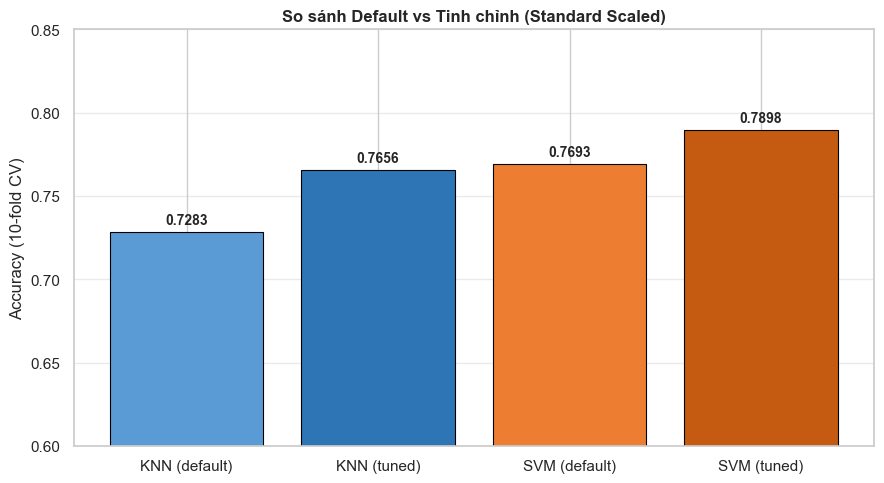

In [17]:
# So sánh Baseline vs Tinh chỉnh (trên Standard Scaled)
tuned_results = {
    'KNN (default)': baseline_results['KNN']['Standard Scaled'].mean(),
    'KNN (tuned)'  : knn_grid.best_score_,
    'SVM (default)': baseline_results['SVM']['Standard Scaled'].mean(),
    'SVM (tuned)'  : svm_grid.best_score_,
}

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#5B9BD5', '#2E75B6', '#ED7D31', '#C55A11']
bars = ax.bar(tuned_results.keys(), tuned_results.values(),
              color=colors, edgecolor='black', linewidth=0.8)
ax.set_ylabel('Accuracy (10-fold CV)')
ax.set_title('So sánh Default vs Tinh chỉnh (Standard Scaled)', fontweight='bold')
ax.set_ylim(0.6, 0.85)
ax.grid(axis='y', alpha=0.4)
for bar, val in zip(bars, tuned_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Kiểm nghiệm kết quả trên Test (Finalize Model)

### 7.1 Hướng dẫn
+ Sau khi chọn được mô hình tốt nhất qua CV, kiểm nghiệm trên **tập test** (chưa dùng trong quá trình huấn luyện)
+ Đánh giá:
    - **Baselines** – 6 mô hình trên 3 phiên bản dữ liệu
    - **Mô hình tinh chỉnh** – KNN tuned & SVM tuned (Standard Scaled)

In [18]:
# Kiểm nghiệm Baselines trên tập Test
print("KẾT QUẢ TRÊN TẬP TEST – BASELINES")
print("=" * 75)
print(f"{'MODEL':<6} {'RAW':>16} {'MINMAX':>18} {'STANDARD':>18}")
print("=" * 75)

test_baseline_results = {}

for name, model in models_baseline:
    row = {}
    for ds_name, (X_tr, X_te) in datasets.items():
        model.fit(X_tr, y_train)
        acc = accuracy_score(y_test, model.predict(X_te))
        row[ds_name] = acc
    test_baseline_results[name] = row
    r  = row['Raw (Thô)']
    mm = row['MinMax Scaled']
    st = row['Standard Scaled']
    print(f"{name:<6}  {r:.4f}             {mm:.4f}              {st:.4f}")

print("=" * 75)

KẾT QUẢ TRÊN TẬP TEST – BASELINES
MODEL               RAW             MINMAX           STANDARD
LR      0.7403             0.7532              0.7446
LDA     0.7403             0.7403              0.7403
KNN     0.7186             0.7100              0.7143
DT      0.7619             0.7619              0.7619
GNB     0.7446             0.7446              0.7446
SVM     0.7446             0.7359              0.7532


In [19]:
# Kiểm nghiệm mô hình tinh chỉnh trên tập Test
print("KẾT QUẢ TRÊN TẬP TEST – MÔ HÌNH TINH CHỈNH (Standard Scaled)")
print("=" * 55)

# KNN tuned
knn_test_acc = accuracy_score(y_test, best_knn.predict(X_test_std))
print(f"KNN (tuned) : {knn_test_acc:.4f}")
print(classification_report(y_test, best_knn.predict(X_test_std),
                             target_names=['Không bệnh', 'Có bệnh']))

# SVM tuned
svm_test_acc = accuracy_score(y_test, best_svm.predict(X_test_std))
print(f"SVM (tuned) : {svm_test_acc:.4f}")
print(classification_report(y_test, best_svm.predict(X_test_std),
                             target_names=['Không bệnh', 'Có bệnh']))
print("=" * 55)

KẾT QUẢ TRÊN TẬP TEST – MÔ HÌNH TINH CHỈNH (Standard Scaled)
KNN (tuned) : 0.7273
              precision    recall  f1-score   support

  Không bệnh       0.74      0.89      0.81       150
     Có bệnh       0.68      0.42      0.52        81

    accuracy                           0.73       231
   macro avg       0.71      0.66      0.66       231
weighted avg       0.72      0.73      0.71       231

SVM (tuned) : 0.7316
              precision    recall  f1-score   support

  Không bệnh       0.76      0.86      0.81       150
     Có bệnh       0.66      0.49      0.56        81

    accuracy                           0.73       231
   macro avg       0.71      0.68      0.68       231
weighted avg       0.72      0.73      0.72       231



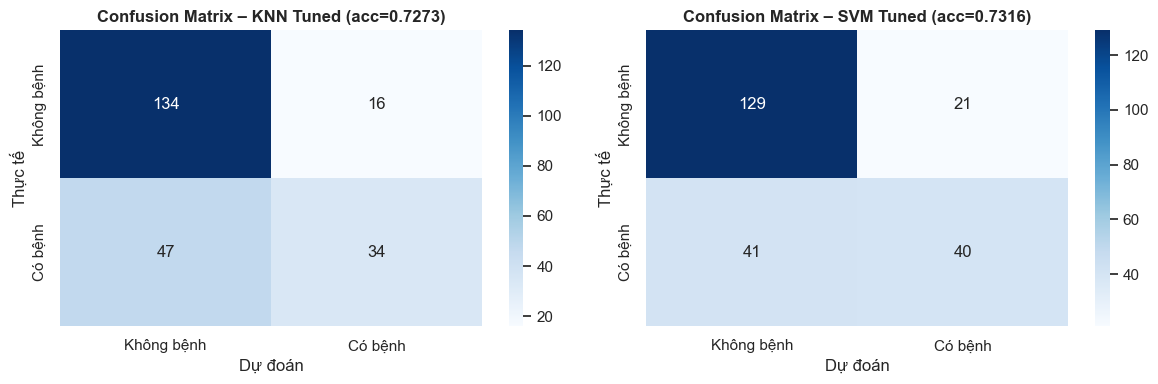

In [20]:
# Confusion Matrix cho mô hình tinh chỉnh
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label, pred) in zip(axes, [
    (f'KNN Tuned (acc={knn_test_acc:.4f})', best_knn.predict(X_test_std)),
    (f'SVM Tuned (acc={svm_test_acc:.4f})', best_svm.predict(X_test_std)),
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Không bệnh', 'Có bệnh'],
                yticklabels=['Không bệnh', 'Có bệnh'])
    ax.set_title(f'Confusion Matrix – {label}', fontweight='bold')
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Thực tế')

plt.tight_layout()
plt.show()

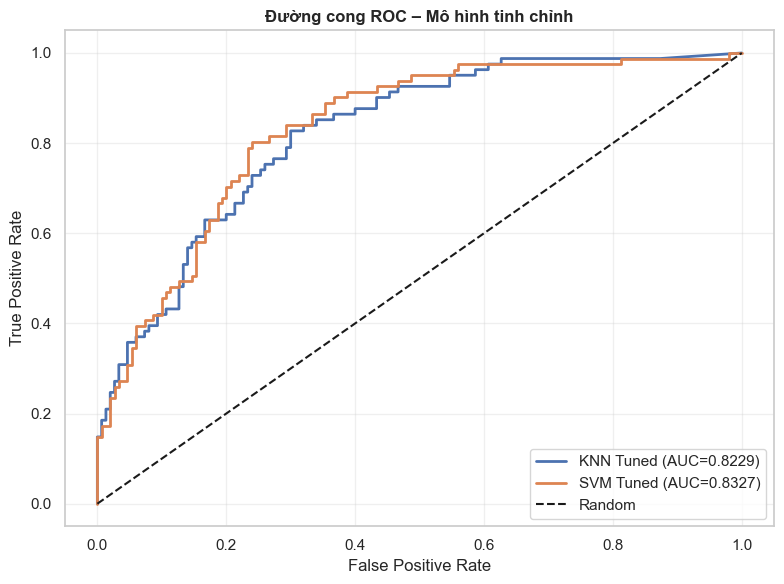

In [21]:
# Đường cong ROC – mô hình tinh chỉnh
fig, ax = plt.subplots(figsize=(8, 6))

for label, model, X_te in [
    ('KNN Tuned', best_knn, X_test_std),
    ('SVM Tuned', best_svm, X_test_std),
]:
    prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, linewidth=2, label=f'{label} (AUC={auc:.4f})')

ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Đường cong ROC – Mô hình tinh chỉnh', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

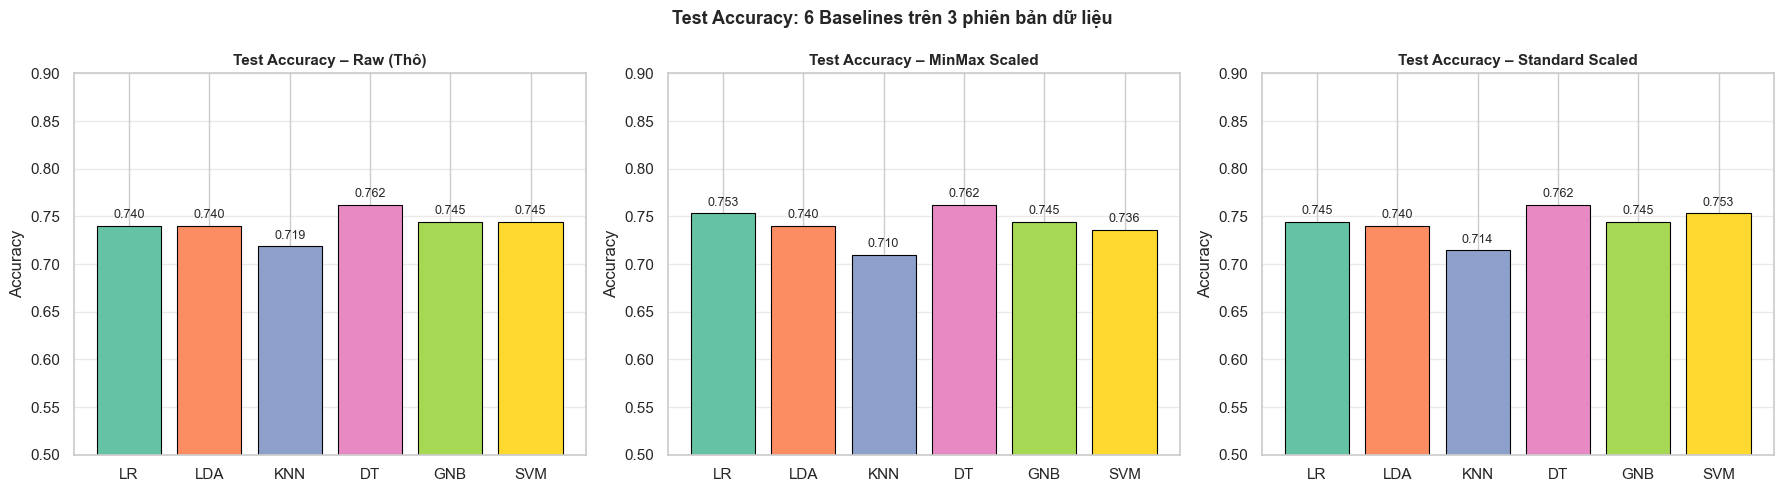

In [22]:
# Tổng hợp so sánh Test Accuracy – tất cả mô hình
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ds_names    = list(datasets.keys())
model_names = list(test_baseline_results.keys())

for ax, ds_name in zip(axes, ds_names):
    accs  = [test_baseline_results[m][ds_name] for m in model_names]
    clrs  = sns.color_palette('Set2', len(model_names))
    bars  = ax.bar(model_names, accs, color=clrs, edgecolor='black', linewidth=0.8)
    ax.set_title(f'Test Accuracy – {ds_name}', fontweight='bold', fontsize=11)
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.5, 0.9)
    ax.grid(axis='y', alpha=0.4)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Test Accuracy: 6 Baselines trên 3 phiên bản dữ liệu',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Lưu kết quả thí nghiệm

In [23]:
# Lưu kết quả thí nghiệm ra file CSV và JSON
save_dir = 'diabetes_results'
os.makedirs(save_dir, exist_ok=True)

# ── Bảng kết quả CV (Baseline) ──
cv_rows = []
for name, row in baseline_results.items():
    for ds_name, scores in row.items():
        cv_rows.append({'Model': name, 'Dataset': ds_name,
                        'CV_Mean': round(scores.mean(), 4),
                        'CV_Std' : round(scores.std(),  4)})
cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv(f'{save_dir}/cv_baseline_results.csv', index=False)
print("✓ cv_baseline_results.csv")

# ── Bảng kết quả Test (Baseline) ──
test_rows = []
for name, row in test_baseline_results.items():
    for ds_name, acc in row.items():
        test_rows.append({'Model': name, 'Dataset': ds_name,
                          'Test_Accuracy': round(acc, 4)})
test_df = pd.DataFrame(test_rows)
test_df.to_csv(f'{save_dir}/test_baseline_results.csv', index=False)
print("✓ test_baseline_results.csv")

# ── Kết quả mô hình tinh chỉnh ──
tuned_summary = {
    'KNN_tuned': {
        'best_params'    : knn_grid.best_params_,
        'cv_accuracy'    : round(knn_grid.best_score_, 4),
        'test_accuracy'  : round(knn_test_acc, 4),
    },
    'SVM_tuned': {
        'best_params'    : svm_grid.best_params_,
        'cv_accuracy'    : round(svm_grid.best_score_, 4),
        'test_accuracy'  : round(svm_test_acc, 4),
    },
    'experiment_config': {
        'total_samples'  : len(df),
        'train_samples'  : len(X_train),
        'test_samples'   : len(X_test),
        'train_test_ratio': '70/30',
        'kfold_k'        : 10,
        'random_state'   : 42,
    }
}

with open(f'{save_dir}/tuned_model_results.json', 'w', encoding='utf-8') as f:
    _json.dump(tuned_summary, f, ensure_ascii=False, indent=4)
print("✓ tuned_model_results.json")

# ── Lưu mô hình tốt nhất ──
joblib.dump(best_knn, f'{save_dir}/knn_tuned.joblib')
joblib.dump(best_svm, f'{save_dir}/svm_tuned.joblib')
joblib.dump(std_scaler,   f'{save_dir}/std_scaler.joblib')
joblib.dump(minmax_scaler, f'{save_dir}/minmax_scaler.joblib')
print("✓ Các mô hình đã lưu")

print(f"\nTất cả kết quả được lưu trong thư mục: '{save_dir}/'")

✓ cv_baseline_results.csv
✓ test_baseline_results.csv
✓ tuned_model_results.json
✓ Các mô hình đã lưu

Tất cả kết quả được lưu trong thư mục: 'diabetes_results/'


## 9. Tóm tắt và Kết luận

In [24]:
print("=" * 65)
print("   TÓM TẮT DỰ ÁN – DỰ ĐOÁN BỆNH TIỂU ĐƯỜNG (BÀI 7)")
print("=" * 65)
print(f"\n1. DỮ LIỆU: Pima Indians Diabetes – {len(df)} mẫu, {X.shape[1]} đặc trưng")
print(f"   Chia Hold-out: 70% train ({len(X_train)} mẫu) / 30% test ({len(X_test)} mẫu)")
print(f"   3 phiên bản: Raw | MinMaxScaler | StandardScaler")

print(f"\n2. BASELINES (10-fold CV trên Standard Scaled):")
for name, row in baseline_results.items():
    sc = row['Standard Scaled']
    print(f"   {name:<5}: {sc.mean():.4f} ± {sc.std():.4f}")

print(f"\n3. TINH CHỈNH (Standard Scaled):")
print(f"   KNN tuned – CV: {knn_grid.best_score_:.4f}  |  Test: {knn_test_acc:.4f}")
print(f"   SVM tuned – CV: {svm_grid.best_score_:.4f}  |  Test: {svm_test_acc:.4f}")
print(f"   KNN best params: {knn_grid.best_params_}")
print(f"   SVM best params: {svm_grid.best_params_}")

best_acc = max(knn_test_acc, svm_test_acc)
best_name = 'KNN Tuned' if knn_test_acc >= svm_test_acc else 'SVM Tuned'
print(f"\n4. KẾT LUẬN: Mô hình tốt nhất = {best_name} (Test Acc = {best_acc:.4f})")
print(f"   Kết quả đã lưu vào thư mục 'diabetes_results/'")
print("=" * 65)

   TÓM TẮT DỰ ÁN – DỰ ĐOÁN BỆNH TIỂU ĐƯỜNG (BÀI 7)

1. DỮ LIỆU: Pima Indians Diabetes – 768 mẫu, 8 đặc trưng
   Chia Hold-out: 70% train (537 mẫu) / 30% test (231 mẫu)
   3 phiên bản: Raw | MinMaxScaler | StandardScaler

2. BASELINES (10-fold CV trên Standard Scaled):
   LR   : 0.7805 ± 0.0624
   LDA  : 0.7749 ± 0.0671
   KNN  : 0.7283 ± 0.0492
   DT   : 0.6835 ± 0.0568
   GNB  : 0.7599 ± 0.0634
   SVM  : 0.7693 ± 0.0390

3. TINH CHỈNH (Standard Scaled):
   KNN tuned – CV: 0.7656  |  Test: 0.7273
   SVM tuned – CV: 0.7898  |  Test: 0.7316
   KNN best params: {'metric': 'manhattan', 'n_neighbors': 23, 'weights': 'distance'}
   SVM best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

4. KẾT LUẬN: Mô hình tốt nhất = SVM Tuned (Test Acc = 0.7316)
   Kết quả đã lưu vào thư mục 'diabetes_results/'
